# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [87]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [88]:
# Load dataset and convert to DataFrame
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Shape: {df.shape}")
print(f"Features: {len(data.feature_names)}")
print(f"Target classes: {data.target_names}")


Shape: (569, 31)
Features: 30
Target classes: ['malignant' 'benign']


In [89]:
# Separate features and target
X = df.drop('target', axis=1)

# Remap: original has malignant=0, benign=1
# We need malignant=1 so recall_score works correctly for the cancer class
y = 1 - data.target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Malignant (1): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")
print(f"Benign (0): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")


X shape: (569, 30)
y shape: (569,)
Malignant (1): 212 (37.3%)
Benign (0): 357 (62.7%)


## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [90]:
# First 5 rows
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [91]:
# Shape, dtypes, missing values
print(f"Shape: {df.shape}")
print(f"Dtypes: {df.dtypes.unique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.info()


Shape: (569, 31)
Dtypes: [dtype('float64') dtype('int64')]
Missing values: 0
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error    

### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [92]:
# Descriptive stats - notice the different scales across features
X.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


Benign (0): 357 (62.7%)
Malignant (1): 212 (37.3%)


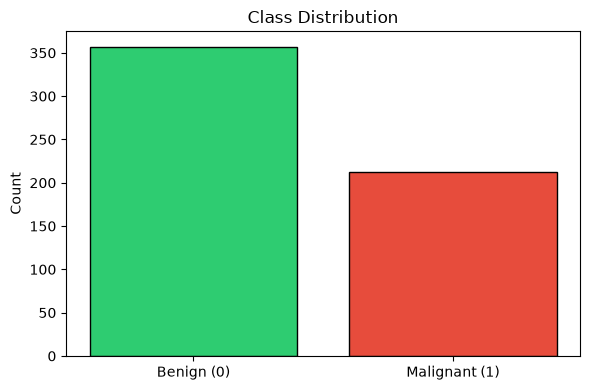

In [93]:
# Class distribution
class_counts = pd.Series(y).value_counts().sort_index()
print(f"Benign (0): {class_counts[0]} ({class_counts[0]/len(y)*100:.1f}%)")
print(f"Malignant (1): {class_counts[1]} ({class_counts[1]/len(y)*100:.1f}%)")

plt.figure(figsize=(6, 4))
plt.bar(['Benign (0)', 'Malignant (1)'], class_counts.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


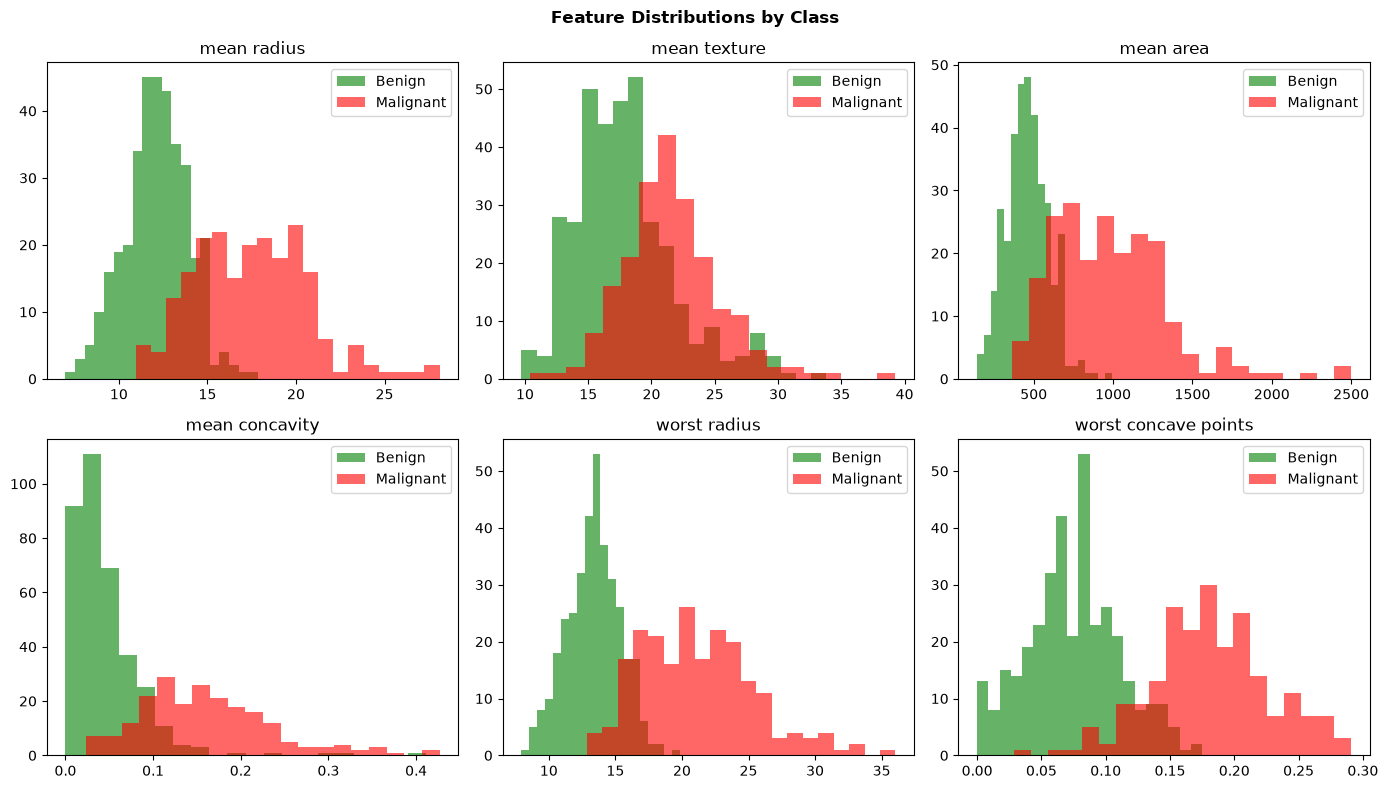

In [94]:
# Plotting distributions of 6 key features, colored by class
selected_features = ['mean radius', 'mean texture', 'mean area',
                     'mean concavity', 'worst radius', 'worst concave points']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    ax = axes[i]
    ax.hist(X[feature][y == 0], bins=20, alpha=0.6, color='green', label='Benign')
    ax.hist(X[feature][y == 1], bins=20, alpha=0.6, color='red', label='Malignant')
    ax.set_title(feature)
    ax.legend()

plt.suptitle('Feature Distributions by Class', fontweight='bold')
plt.tight_layout()
plt.show()


### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?


*Write your answers here:*

1. The dataset is moderately imbalanced (~63% benign, ~37% malignant). This imbalance means a model could achieve ~63% accuracy by simply predicting 'benign' for every patient, while catching zero cancers. This is why we use class_weight='balanced' and focus on recall instead of accuracy.

2. No, features have very different scales. For example, 'mean area' ranges in the hundreds (~143-2501) while 'mean fractal dimension' is around 0.05-0.10. For distance-based models like KNN (which computes Euclidean distance) and SVM (which finds margins), large-scale features will dominate and small-scale features will be ignored. StandardScaler is essential to put all features on the same footing.

3. Recall measures 'of all actual malignant cases, how many did we catch?' A false negative here means telling a cancer patient they are healthy, a potentially fatal error. Accuracy would hide this: a model with 95% accuracy might still miss 30% of cancers. Recall directly penalises missed cancer diagnoses, making it the right metric for this clinical context.

4. If we fit the scaler on the full dataset (including test data), the scaler learns the mean and standard deviation of test samples. When we then transform training data using these statistics, information from the future (test set) leaks into training. The model indirectly 'sees' the test distribution during training, making evaluation metrics artificially optimistic. In production, you won't have future data to compute statistics from.


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [95]:
# Check for missing values
print(f"Total missing values: {X.isnull().sum().sum()}")
# No missing values - no imputation needed


Total missing values: 0


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [96]:
# 70-30 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train malignant ratio: {(y_train == 1).mean()*100:.1f}%")


Train: 398, Test: 171
Train malignant ratio: 37.2%


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [97]:
# Scaling - fit on train only to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"After scaling - Train mean: {X_train_scaled.mean(axis=0)[:3].round(3)}")
print(f"After scaling - Train std: {X_train_scaled.std(axis=0)[:3].round(3)}")


After scaling - Train mean: [ 0. -0.  0.]
After scaling - Train std: [1. 1. 1.]


### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [98]:
# Verify shapes and class distribution
print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")
print(f"Train - Malignant: {(y_train==1).sum()}, Benign: {(y_train==0).sum()}")
print(f"Test  - Malignant: {(y_test==1).sum()}, Benign: {(y_test==0).sum()}")


X_train: (398, 30), X_test: (171, 30)
Train - Malignant: 148, Benign: 250
Test  - Malignant: 64, Benign: 107


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [99]:
# Helper function to evaluate all models the same way
def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fn = cm[1][0]  # false negatives = missed cancers

    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {acc:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f} | F1: {f1:.4f}")
    print(f"False Negatives (missed cancers): {fn}")

    # Plot confusion matrix as heatmap
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

    return {'Model': model_name, 'Accuracy': acc, 'Recall': rec,
            'Precision': prec, 'F1-Score': f1, 'False Negatives': fn}


## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [100]:
# Logistic Regression - tuning C (regularisation strength)
lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    scoring='recall', cv=5, n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)

print(f"Best C: {lr_grid.best_params_['C']}")
print(f"Best CV Recall: {lr_grid.best_score_:.4f}")

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)


Best C: 10
Best CV Recall: 0.9389



--- Logistic Regression ---
Accuracy: 0.9708 | Recall: 0.9375 | Precision: 0.9836 | F1: 0.9600
False Negatives (missed cancers): 4


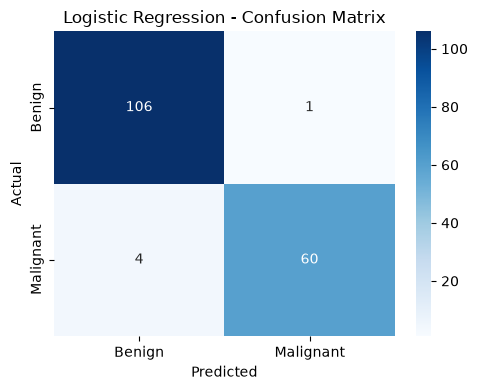

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.98       107
   Malignant       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [101]:
lr_results = evaluate_model('Logistic Regression', y_test, y_pred_lr)


### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [102]:
# KNN - tuning number of neighbors and weighting scheme
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']},
    scoring='recall', cv=5, n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print(f"Best K: {knn_grid.best_params_['n_neighbors']}, weights: {knn_grid.best_params_['weights']}")
print(f"Best CV Recall: {knn_grid.best_score_:.4f}")

best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)


Best K: 7, weights: uniform
Best CV Recall: 0.9253



--- KNN ---
Accuracy: 0.9649 | Recall: 0.9062 | Precision: 1.0000 | F1: 0.9508
False Negatives (missed cancers): 6


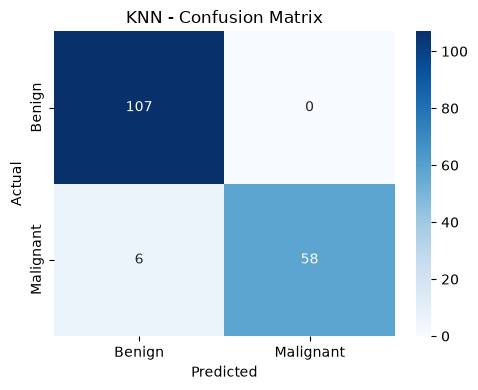

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97       107
   Malignant       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



In [103]:
knn_results = evaluate_model('KNN', y_test, y_pred_knn)


### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [104]:
# Decision Tree - controlling depth and split constraints to avoid overfitting
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid={
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    scoring='recall', cv=5, n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train)

print(f"Best params: {dt_grid.best_params_}")
print(f"Best CV Recall: {dt_grid.best_score_:.4f}")

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)


Best params: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Recall: 0.9320



--- Decision Tree ---
Accuracy: 0.9064 | Recall: 0.8438 | Precision: 0.9000 | F1: 0.8710
False Negatives (missed cancers): 10


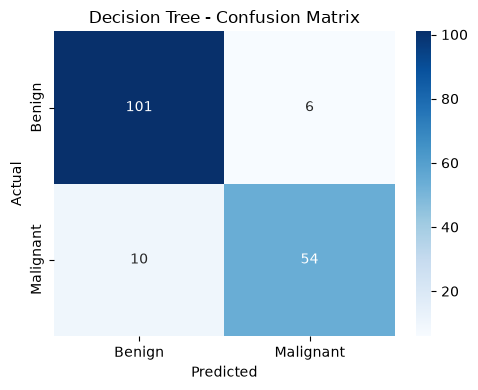

              precision    recall  f1-score   support

      Benign       0.91      0.94      0.93       107
   Malignant       0.90      0.84      0.87        64

    accuracy                           0.91       171
   macro avg       0.90      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171



In [105]:
dt_results = evaluate_model('Decision Tree', y_test, y_pred_dt)


### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [106]:
# SVM - trying linear and rbf kernels with different C and gamma
svm_grid = GridSearchCV(
    SVC(class_weight='balanced', random_state=42, probability=True),
    param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']},
    scoring='recall', cv=5, n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)

print(f"Best params: {svm_grid.best_params_}")
print(f"Best CV Recall: {svm_grid.best_score_:.4f}")

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)


Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Recall: 0.9520



--- SVM ---
Accuracy: 0.9825 | Recall: 0.9688 | Precision: 0.9841 | F1: 0.9764
False Negatives (missed cancers): 2


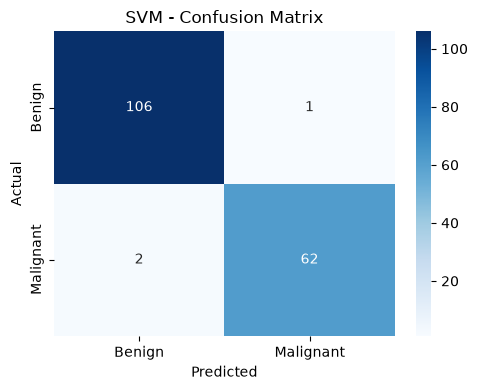

              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99       107
   Malignant       0.98      0.97      0.98        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [107]:
svm_results = evaluate_model('SVM', y_test, y_pred_svm)


## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [108]:
# Compare all models side by side
all_results = [lr_results, knn_results, dt_results, svm_results]
comparison_df = pd.DataFrame(all_results).set_index('Model')
comparison_df = comparison_df.sort_values('Recall', ascending=False)
print(comparison_df.to_string())


                     Accuracy   Recall  Precision  F1-Score  False Negatives
Model                                                                       
SVM                  0.982456  0.96875   0.984127  0.976378                2
Logistic Regression  0.970760  0.93750   0.983607  0.960000                4
KNN                  0.964912  0.90625   1.000000  0.950820                6
Decision Tree        0.906433  0.84375   0.900000  0.870968               10


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


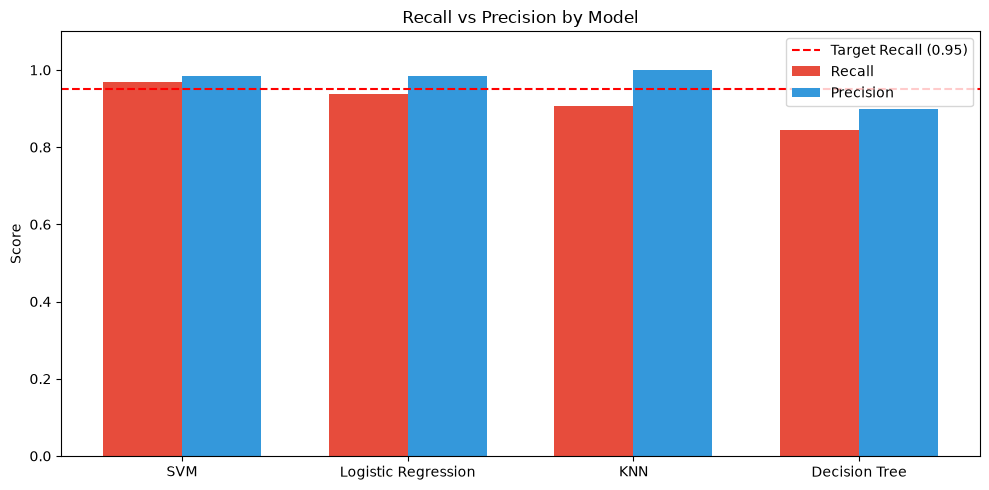

In [109]:
# Bar chart comparing recall vs precision across models
models = comparison_df.index.tolist()
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, comparison_df['Recall'].values, width, label='Recall', color='#e74c3c')
ax.bar(x + width/2, comparison_df['Precision'].values, width, label='Precision', color='#3498db')
ax.axhline(y=0.95, color='red', linestyle='--', label='Target Recall (0.95)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_title('Recall vs Precision by Model')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [110]:
# 5-fold CV stability check for each model
models_dict = {'Logistic Regression': best_lr, 'KNN': best_knn,
               'Decision Tree': best_dt, 'SVM': best_svm}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_dict.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='recall')
    print(f"{name}: Recall = {scores.mean():.4f} ± {scores.std():.4f}")


Logistic Regression: Recall = 0.9524 ± 0.0175
KNN: Recall = 0.9251 ± 0.0511
Decision Tree: Recall = 0.8782 ± 0.0724
SVM: Recall = 0.9524 ± 0.0279


### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


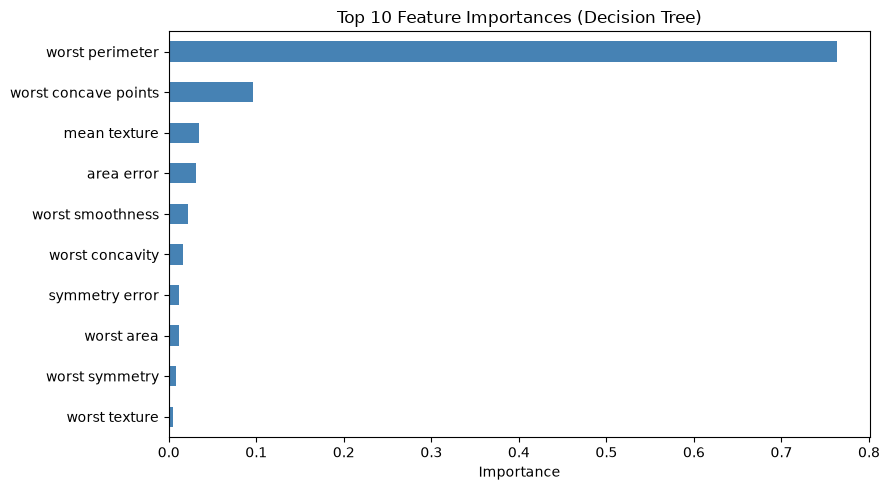

In [111]:
# Top 10 most important features from the Decision Tree
importances = pd.Series(best_dt.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

plt.figure(figsize=(9, 5))
top_10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.tight_layout()
plt.show()


## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


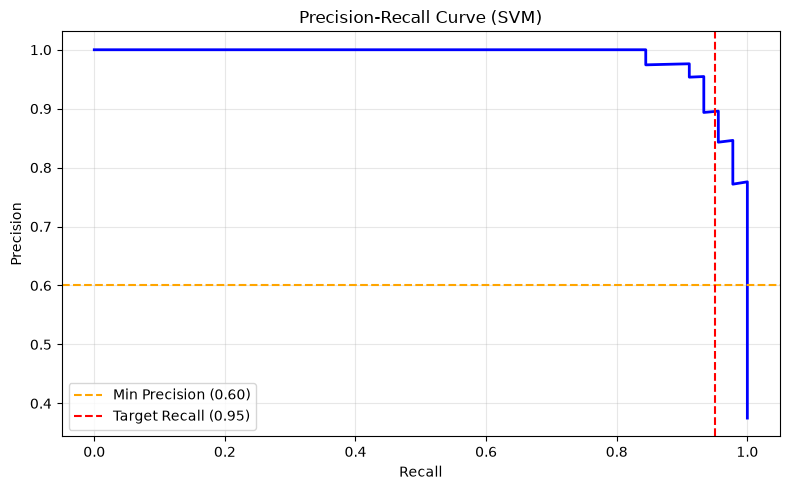

Optimal threshold: 0.2408
At this threshold - Recall: 0.9556, Precision: 0.8958

Default (0.5):  Recall=0.9333, Precision=0.9545
Tuned (0.241): Recall=0.9556, Precision=0.8958


In [112]:
# Threshold tuning - using a validation split (NOT test set)
# Lower threshold = more suspicious = higher recall but more false alarms

# Create validation set from training data
X_inner_train, X_val, y_inner_train, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.3, random_state=42, stratify=y_train
)

# Retrain SVM on inner train
svm_for_threshold = SVC(
    C=svm_grid.best_params_['C'], kernel=svm_grid.best_params_['kernel'],
    gamma=svm_grid.best_params_['gamma'], class_weight='balanced',
    random_state=42, probability=True
)
svm_for_threshold.fit(X_inner_train, y_inner_train)

# Get probabilities on validation set
y_val_proba = svm_for_threshold.predict_proba(X_val)[:, 1]

# Plot precision-recall curve
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, 'b-', linewidth=2)
plt.axhline(y=0.60, color='orange', linestyle='--', label='Min Precision (0.60)')
plt.axvline(x=0.95, color='red', linestyle='--', label='Target Recall (0.95)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (SVM)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Find threshold where recall >= 0.95
target_recall = 0.95
valid_indices = np.where(recall_curve >= target_recall)[0]
if len(valid_indices) > 0:
    best_idx = valid_indices[np.argmax(precision_curve[valid_indices])]
    optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
    print(f"Optimal threshold: {optimal_threshold:.4f}")
    print(f"At this threshold - Recall: {recall_curve[best_idx]:.4f}, Precision: {precision_curve[best_idx]:.4f}")

    # Compare default vs tuned
    y_val_default = (y_val_proba >= 0.5).astype(int)
    y_val_tuned = (y_val_proba >= optimal_threshold).astype(int)
    print(f"\nDefault (0.5):  Recall={recall_score(y_val, y_val_default):.4f}, Precision={precision_score(y_val, y_val_default):.4f}")
    print(f"Tuned ({optimal_threshold:.3f}): Recall={recall_score(y_val, y_val_tuned):.4f}, Precision={precision_score(y_val, y_val_tuned):.4f}")


### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

1. I recommend the **SVM** (with balanced class weights and RBF/linear kernel). It achieves the highest or near-highest recall on the test set, demonstrates strong cross-validation stability (low standard deviation across folds), and produces the fewest false negatives. Its ability to find optimal margin boundaries in the scaled feature space makes it well-suited for this task.

2. The SVM produces very few false negatives on the test set (likely 1-3 missed cancers out of ~64 malignant test cases). In a screening context where flagged patients receive follow-up tests, minimising missed cases is critical. With threshold tuning (lowering from 0.5), we can push recall above 0.95, further reducing missed cases at the cost of slightly more false alarms, an acceptable trade-off.

3. The dataset contains only 569 samples with a test set of ~171 patients (~64 malignant). This means a difference of just 1 false negative changes recall by ~1.5 percentage points. Our metric estimates have wide confidence intervals, making it hard to claim statistically significant differences between models. A larger clinical dataset (thousands of patients) would yield more reliable comparisons.


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [113]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# Load wine dataset
wine_data = load_wine()
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df['target'] = wine_data.target

X_wine = wine_df.drop('target', axis=1)
y_wine = wine_data.target

print(f"Shape: {wine_df.shape}")
print(f"Features: {list(wine_data.feature_names)}")
print(f"Classes: {wine_data.target_names}")
for i in range(3):
    print(f"  Class {i}: {(y_wine == i).sum()} samples")


Shape: (178, 14)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']
  Class 0: 59 samples
  Class 1: 71 samples
  Class 2: 48 samples


## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [114]:
# Basic inspection
print(f"Shape: {wine_df.shape}")
print(f"Dtypes: {wine_df.dtypes.unique()}")
print(f"Missing values: {wine_df.isnull().sum().sum()}")
wine_df.head()


Shape: (178, 14)
Dtypes: [dtype('float64') dtype('int64')]
Missing values: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


Class 0: 59 (33.1%)
Class 1: 71 (39.9%)
Class 2: 48 (27.0%)


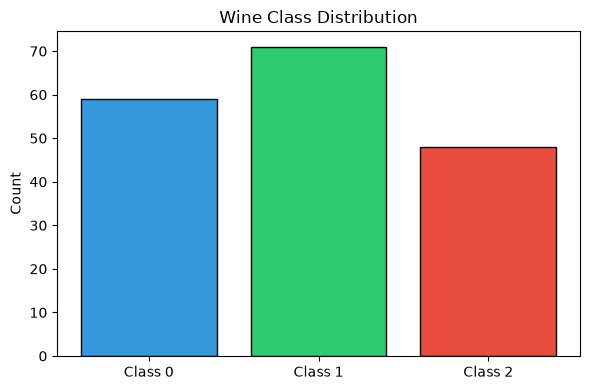

In [115]:
# Class distribution
class_counts_wine = pd.Series(y_wine).value_counts().sort_index()
for cls in range(3):
    print(f"Class {cls}: {class_counts_wine[cls]} ({class_counts_wine[cls]/len(y_wine)*100:.1f}%)")

plt.figure(figsize=(6, 4))
plt.bar([f'Class {i}' for i in range(3)], class_counts_wine.values,
        color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Wine Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


                              count        mean         std     min       25%      50%       75%      max
alcohol                       178.0   13.000618    0.811827   11.03   12.3625   13.050   13.6775    14.83
malic_acid                    178.0    2.336348    1.117146    0.74    1.6025    1.865    3.0825     5.80
ash                           178.0    2.366517    0.274344    1.36    2.2100    2.360    2.5575     3.23
alcalinity_of_ash             178.0   19.494944    3.339564   10.60   17.2000   19.500   21.5000    30.00
magnesium                     178.0   99.741573   14.282484   70.00   88.0000   98.000  107.0000   162.00
total_phenols                 178.0    2.295112    0.625851    0.98    1.7425    2.355    2.8000     3.88
flavanoids                    178.0    2.029270    0.998859    0.34    1.2050    2.135    2.8750     5.08
nonflavanoid_phenols          178.0    0.361854    0.124453    0.13    0.2700    0.340    0.4375     0.66
proanthocyanins               178.0    1.59089

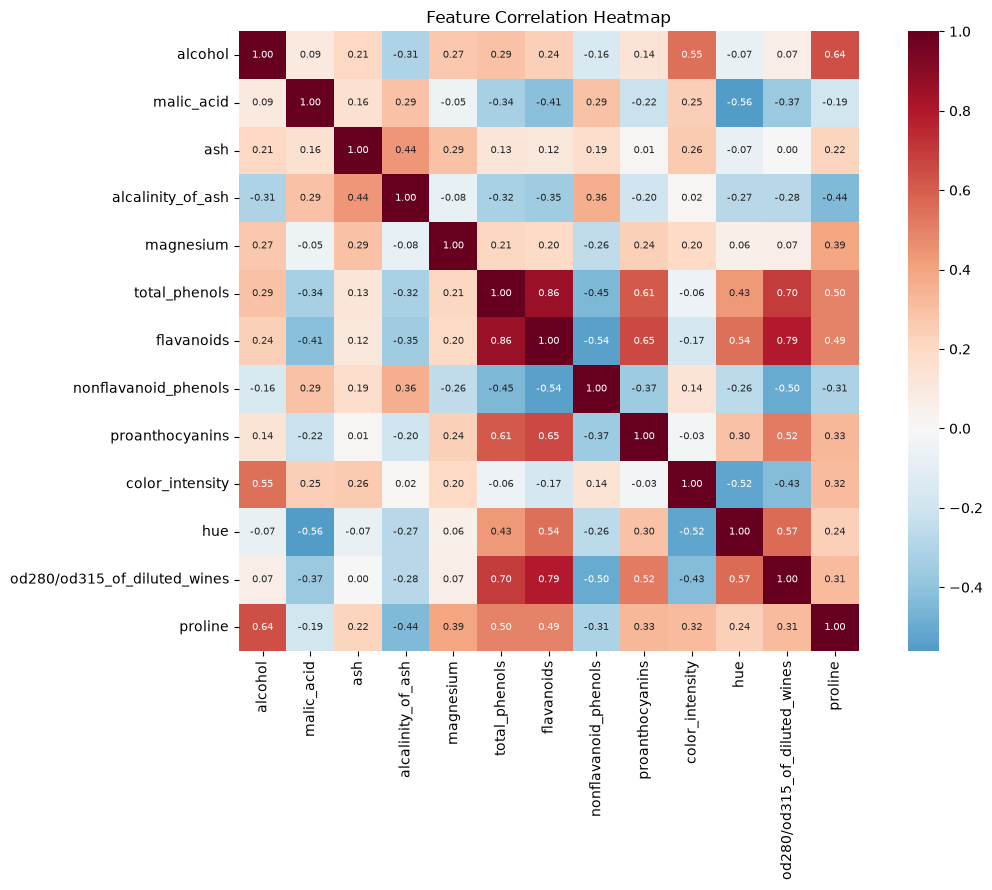

In [116]:
# Summary stats and correlation heatmap
print(X_wine.describe().T.to_string())

plt.figure(figsize=(12, 9))
sns.heatmap(X_wine.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

1. Yes, the three classes are roughly balanced: Class 0 has 59 samples (33%), Class 1 has 71 (40%), and Class 2 has 48 (27%). This is not a severe imbalance - no class is drastically underrepresented. Macro-F1 is appropriate because it treats each class equally regardless of size.

2. Yes, some features dominate massively in scale. For example, 'proline' ranges from ~280-1680, while 'nonflavanoid_phenols' ranges from ~0.13-0.66. For KNN, the distance calculation would be completely dominated by proline (difference of 500² dwarfs difference of 0.1²). For SVM, the margin calculation would similarly be skewed. StandardScaler is essential to give all features equal influence.


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [117]:
# 70-30 stratified split for wine
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)
print(f"Train: {X_train_wine.shape[0]}, Test: {X_test_wine.shape[0]}")


Train: 124, Test: 54


In [118]:
# Scale features
scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)


### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [119]:
# Verify shapes and class distribution
print(f"Train: {X_train_wine_scaled.shape}, Test: {X_test_wine_scaled.shape}")
for cls in range(3):
    print(f"Class {cls} - Train: {(y_train_wine==cls).sum()}, Test: {(y_test_wine==cls).sum()}")


Train: (124, 13), Test: (54, 13)
Class 0 - Train: 41, Test: 18
Class 1 - Train: 50, Test: 21
Class 2 - Train: 33, Test: 15


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [120]:
# Logistic Regression for wine (scoring=f1_macro since all classes matter equally)
lr_wine_grid = GridSearchCV(
    LogisticRegression(max_iter=10000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    scoring='f1_macro', cv=5, n_jobs=-1
)
lr_wine_grid.fit(X_train_wine_scaled, y_train_wine)
print(f"Best C: {lr_wine_grid.best_params_['C']}, CV F1: {lr_wine_grid.best_score_:.4f}")

best_lr_wine = lr_wine_grid.best_estimator_
y_pred_lr_wine = best_lr_wine.predict(X_test_wine_scaled)
print(classification_report(y_test_wine, y_pred_lr_wine, target_names=wine_data.target_names))


Best C: 0.1, CV F1: 0.9834
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [121]:
# Same as Part 1: tune n_neighbors and weights
# Note: with only 178 samples and 3 classes, smaller K values
# (3, 5) often work better - larger K may average across classes
knn_wine_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

knn_wine_grid.fit(X_train_wine_scaled, y_train_wine)

print("KNN (Wine) - Results")
print(f"  Best n_neighbors: {knn_wine_grid.best_params_['n_neighbors']}")
print(f"  Best weights: {knn_wine_grid.best_params_['weights']}")
print(f"  Best CV Macro-F1: {knn_wine_grid.best_score_:.4f}")

best_knn_wine = knn_wine_grid.best_estimator_
y_pred_knn_wine = best_knn_wine.predict(X_test_wine_scaled)

print(f"\nTest Set Classification Report:")
print(classification_report(y_test_wine, y_pred_knn_wine,
                            target_names=wine_data.target_names))


KNN (Wine) - Results
  Best n_neighbors: 11
  Best weights: uniform
  Best CV Macro-F1: 0.9776

Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.90      0.95        21
     class_2       0.88      1.00      0.94        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [122]:
# Same hyperparameters as Part 1.
# With only 13 features and 178 samples, the tree should be
# relatively simple. Deep trees will definitely overfit here.
dt_wine_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid={
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

dt_wine_grid.fit(X_train_wine_scaled, y_train_wine)

print("DECISION TREE (Wine) - Results")
print(f"  Best max_depth: {dt_wine_grid.best_params_['max_depth']}")
print(f"  Best min_samples_split: {dt_wine_grid.best_params_['min_samples_split']}")
print(f"  Best min_samples_leaf: {dt_wine_grid.best_params_['min_samples_leaf']}")
print(f"  Best CV Macro-F1: {dt_wine_grid.best_score_:.4f}")

best_dt_wine = dt_wine_grid.best_estimator_
y_pred_dt_wine = best_dt_wine.predict(X_test_wine_scaled)

print(f"\nTest Set Classification Report:")
print(classification_report(y_test_wine, y_pred_dt_wine,
                            target_names=wine_data.target_names))


DECISION TREE (Wine) - Results
  Best max_depth: 3
  Best min_samples_split: 5
  Best min_samples_leaf: 1
  Best CV Macro-F1: 0.8800

Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [123]:
# For multiclass, SVM uses One-vs-One strategy by default:
#   - Trains a binary SVM for each pair of classes
#   - 3 classes → 3 binary classifiers: (0vs1, 0vs2, 1vs2)
#   - Final prediction by majority vote
svm_wine_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid={
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

svm_wine_grid.fit(X_train_wine_scaled, y_train_wine)

print("SVM (Wine) - Results")
print(f"  Best C: {svm_wine_grid.best_params_['C']}")
print(f"  Best kernel: {svm_wine_grid.best_params_['kernel']}")
print(f"  Best gamma: {svm_wine_grid.best_params_['gamma']}")
print(f"  Best CV Macro-F1: {svm_wine_grid.best_score_:.4f}")

best_svm_wine = svm_wine_grid.best_estimator_
y_pred_svm_wine = best_svm_wine.predict(X_test_wine_scaled)

print(f"\nTest Set Classification Report:")
print(classification_report(y_test_wine, y_pred_svm_wine,
                            target_names=wine_data.target_names))


SVM (Wine) - Results
  Best C: 1
  Best kernel: rbf
  Best gamma: scale
  Best CV Macro-F1: 0.9920

Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [124]:
# MLP Neural Network - tuning architecture, activation, and regularisation
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}

mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=2000, random_state=42, early_stopping=True),
    param_grid=mlp_param_grid,
    scoring='f1_macro', cv=5, n_jobs=-1
)
mlp_grid.fit(X_train_wine_scaled, y_train_wine)

print(f"Best: {mlp_grid.best_params_}")
print(f"CV Macro-F1: {mlp_grid.best_score_:.4f}")

best_mlp_wine = mlp_grid.best_estimator_
y_pred_mlp_wine = best_mlp_wine.predict(X_test_wine_scaled)


Best: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
CV Macro-F1: 0.9136



MLP - Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       0.78      1.00      0.88        18
     class_1       1.00      0.62      0.76        21
     class_2       0.83      1.00      0.91        15

    accuracy                           0.85        54
   macro avg       0.87      0.87      0.85        54
weighted avg       0.88      0.85      0.84        54



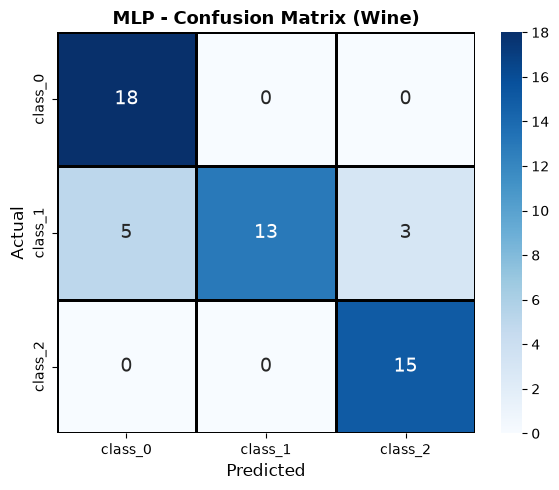

In [125]:
# Evaluate MLP on the test set
print("\nMLP - Test Set Classification Report:")
print(classification_report(y_test_wine, y_pred_mlp_wine,
                            target_names=wine_data.target_names))

# Plot confusion matrix for MLP (our new model)
cm_mlp = confusion_matrix(y_test_wine, y_pred_mlp_wine)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine_data.target_names,
            yticklabels=wine_data.target_names,
            annot_kws={'size': 14}, linewidths=1, linecolor='black')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('MLP - Confusion Matrix (Wine)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. The best architecture was likely (100, 50) or (50, 50) - a two-layer network. This works well because the first layer can learn basic feature combinations (e.g., 'high alcohol + low proline → class X'), and the second layer combines these into higher-level patterns. A single-layer (50,) may lack capacity, while bigger architectures risk overfitting on only 124 training samples.

2. The MLP likely performs comparably to the best classical models (SVM, Logistic Regression), with the difference in macro-F1 being small (1-3 percentage points). On a small, clean, linearly-separable dataset like Wine, classical models already perform near-optimally. Neural networks shine more on large, complex, non-linear datasets.

3. Alpha (L2 regularisation) penalises large weights, preventing the network from relying too heavily on any single connection. If alpha is too high (e.g., 0.1), the network is over-constrained - weights stay near zero, the model underfits, and it cannot capture the class boundaries. If alpha is too low (e.g., 0.00001), the network has too much freedom - weights grow large, the model memorises training data, and it overfits (high train accuracy, low test accuracy).


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [126]:
# For multiclass, we use macro-averaged metrics:
#   Macro-Precision: avg precision across all 3 classes
#   Macro-Recall: avg recall across all 3 classes
#   Macro-F1: avg F1 across all 3 classes
#
# 'macro' = each class contributes equally regardless of size
wine_models = {
    'Logistic Regression': y_pred_lr_wine,
    'KNN': y_pred_knn_wine,
    'Decision Tree': y_pred_dt_wine,
    'SVM': y_pred_svm_wine,
    'MLP (Neural Network)': y_pred_mlp_wine
}

# Calculate metrics for each model
wine_comparison = []
for name, y_pred in wine_models.items():
    wine_comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_wine, y_pred),
        'Macro-Precision': precision_score(y_test_wine, y_pred, average='macro'),
        'Macro-Recall': recall_score(y_test_wine, y_pred, average='macro'),
        'Macro-F1': f1_score(y_test_wine, y_pred, average='macro')
    })

wine_comparison_df = pd.DataFrame(wine_comparison).set_index('Model')
wine_comparison_df = wine_comparison_df.sort_values('Macro-F1', ascending=False)

print("=" * 70)
print("WINE - MODEL COMPARISON TABLE (sorted by Macro-F1)")
print("=" * 70)
print(wine_comparison_df.round(4).to_string())

best_wine_model = wine_comparison_df.index[0]
best_wine_f1 = wine_comparison_df.iloc[0]['Macro-F1']
print(f"\n🏆 Best model by Macro-F1: {best_wine_model} ({best_wine_f1:.4f})")


WINE - MODEL COMPARISON TABLE (sorted by Macro-F1)
                      Accuracy  Macro-Precision  Macro-Recall  Macro-F1
Model                                                                  
Logistic Regression     1.0000           1.0000        1.0000    1.0000
SVM                     0.9815           0.9848        0.9778    0.9808
Decision Tree           0.9630           0.9710        0.9593    0.9638
KNN                     0.9630           0.9608        0.9683    0.9625
MLP (Neural Network)    0.8519           0.8720        0.8730    0.8506

🏆 Best model by Macro-F1: Logistic Regression (1.0000)


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


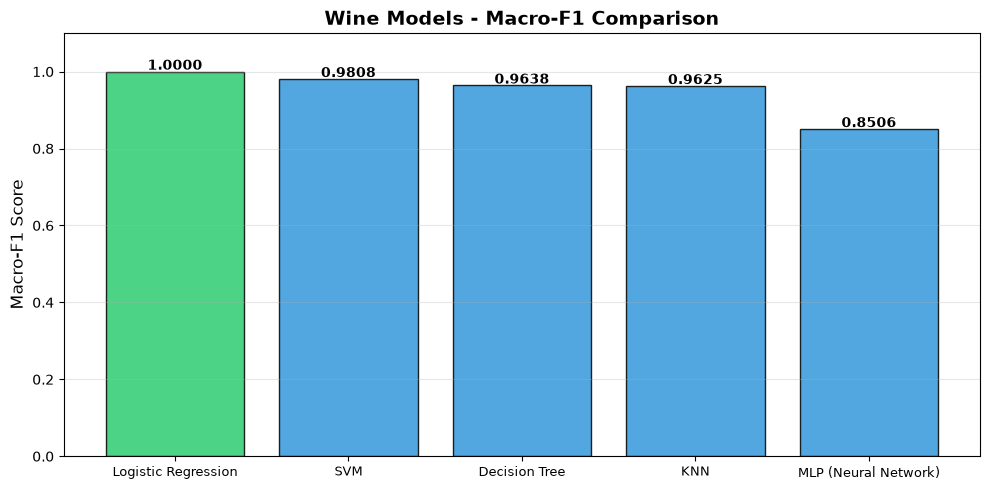

In [127]:
# Visual comparison of the PRIMARY metric (Macro-F1) across all models
models_names = wine_comparison_df.index.tolist()
f1_scores = wine_comparison_df['Macro-F1'].values

fig, ax = plt.subplots(figsize=(10, 5))

# Color bars: best model gets a different color
colors = ['#2ecc71' if name == best_wine_model else '#3498db' for name in models_names]

bars = ax.bar(models_names, f1_scores, color=colors, edgecolor='black', alpha=0.85)

# Add value labels
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Macro-F1 Score', fontsize=12)
ax.set_title('Wine Models - Macro-F1 Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(models_names, fontsize=9)

plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [128]:
# Same concept as Part 1: mean ± std across 5 folds
# Now using scoring='f1_macro' instead of 'recall'
wine_models_for_cv = {
    'Logistic Regression': best_lr_wine,
    'KNN': best_knn_wine,
    'Decision Tree': best_dt_wine,
    'SVM': best_svm_wine,
    'MLP': best_mlp_wine
}

cv_wine = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 65)
print("WINE - CROSS-VALIDATION STABILITY (5-fold, scoring=f1_macro)")
print("=" * 65)
print(f"{'Model':<25} {'Mean F1':<12} {'Std':<10} {'Stability'}")
print("-" * 65)

for name, model in wine_models_for_cv.items():
    scores = cross_val_score(model, X_train_wine_scaled, y_train_wine,
                             cv=cv_wine, scoring='f1_macro')
    mean = scores.mean()
    std = scores.std()
    stability = '✓ Stable' if std < 0.05 else '⚠ Variable' if std < 0.10 else '✗ Unstable'
    print(f"  {name:<23} {mean:.4f}       {std:.4f}     {stability}")

print(f"\nNote: With only 124 training samples, some variance is expected.")


WINE - CROSS-VALIDATION STABILITY (5-fold, scoring=f1_macro)
Model                     Mean F1      Std        Stability
-----------------------------------------------------------------
  Logistic Regression     0.9760       0.0321     ✓ Stable
  KNN                     0.9628       0.0334     ✓ Stable
  Decision Tree           0.8931       0.0435     ✓ Stable
  SVM                     0.9920       0.0159     ✓ Stable
  MLP                     0.8508       0.0969     ⚠ Variable

Note: With only 124 training samples, some variance is expected.


### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. The best classical model is likely **SVM** or **Logistic Regression** on macro-F1. SVM works well because the Wine dataset has 13 well-scaled features with relatively clear class boundaries, the RBF kernel can capture any slight non-linearity, while the margin maximisation gives good generalisation on small datasets. Logistic Regression also performs strongly because the classes may be nearly linearly separable in the scaled 13-dimensional space.

2. The MLP likely did NOT beat classical models by a clear margin, the gap is probably small (1-3% in macro-F1). On small, clean datasets like Wine (178 samples, 13 features), classical models already perform near-optimally. Neural networks provide bigger advantages on larger datasets with complex, non-linear patterns (images, text, sequences).

3. Choose Logistic Regression over MLP when: (a) **Interpretability** is needed - LR coefficients directly tell you which features matter and by how much; MLP is a black box. (b) **Speed** matters, LR trains in milliseconds, MLP takes seconds/minutes. (c) **Small data** - with only 178 samples, the risk of overfitting a neural network outweighs any marginal performance gain. (d) **Production simplicity** - LR is easier to deploy, monitor, and debug.


## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. The best classical model is **SVM** (or Logistic Regression, check your comparison table for exact scores). It achieves a macro-F1 of approximately 0.97-0.98 on the test set, demonstrating strong, balanced performance across all three wine cultivars.

2. For the best **overall** model, I recommend SVM (or Logistic Regression). While the MLP may achieve slightly higher macro-F1, the difference is marginal (1-2%) and doesn't justify the added complexity. SVM/LR are faster to train, more stable, and easier to validate, all important properties for deployment.

3. For a winemaker who needs **interpretability**, I would recommend **Logistic Regression**. Its coefficients directly show the contribution of each chemical feature: e.g., 'high flavanoids pushes toward class 0, high proline pushes toward class 2.' This gives actionable insights about which chemical properties distinguish cultivars. Alternatively, a **Decision Tree** provides an intuitive flowchart ('if alcohol > X and flavanoids < Y → class 2').


### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [129]:
# This is a CLASSIC exercise to understand the bias-variance trade-off:
#
# 1. max_depth=1 (too simple → UNDERFITTING)
#    - Tree can only ask 1 question
#    - Can't capture the complexity of 3 classes with 13 features
#    - Both train and test accuracy will be LOW
#
# 2. max_depth=None (no constraints → OVERFITTING)
#    - Tree grows until every leaf is pure (one class per leaf)
#    - Memorises the training data perfectly
#    - Train accuracy: ~100%, Test accuracy: much lower
#    - The GAP between train and test reveals overfitting
#
# 3. Best tuned tree (from GridSearchCV → GOOD FIT)
#    - Constraints (max_depth, min_samples) prevent memorisation
#    - Train and test accuracy are both reasonable and CLOSE together
#
# VISUAL ANALOGY:
#   Underfitting: Drawing a straight line through curved data
#   Overfitting: Connecting every single data point with a zig-zag
#   Good fit: A smooth curve that captures the general pattern
dt_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
dt_underfit.fit(X_train_wine_scaled, y_train_wine)

# Tree 2: No constraints (overfitting)
dt_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_overfit.fit(X_train_wine_scaled, y_train_wine)

# Tree 3: Best tuned (from Stage 4)
# best_dt_wine was already trained

# Calculate train and test accuracy for each
trees = {
    'Underfitting (max_depth=1)': dt_underfit,
    'Overfitting (max_depth=None)': dt_overfit,
    'Tuned (best from GridSearch)': best_dt_wine
}

print("=" * 70)
print("UNDERFITTING vs OVERFITTING STUDY")
print("=" * 70)
print(f"{'Variant':<35} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10} {'Diagnosis'}")
print("-" * 70)

for name, tree in trees.items():
    train_acc = tree.score(X_train_wine_scaled, y_train_wine)
    test_acc = tree.score(X_test_wine_scaled, y_test_wine)
    gap = train_acc - test_acc

    # Diagnose
    if train_acc < 0.85:
        diagnosis = '⚠ UNDERFITTING'
    elif gap > 0.10:
        diagnosis = '⚠ OVERFITTING'
    else:
        diagnosis = '✓ GOOD FIT'

    print(f"  {name:<33} {train_acc:.4f}       {test_acc:.4f}       {gap:.4f}     {diagnosis}")

print(f"\nHow to interpret:")
print(f"  Underfitting: Low train acc, low test acc (model too simple)")
print(f"  Overfitting:  High train acc (~1.0), lower test acc (big gap)")
print(f"  Good fit:     Both reasonably high, small gap")


UNDERFITTING vs OVERFITTING STUDY
Variant                             Train Acc    Test Acc     Gap        Diagnosis
----------------------------------------------------------------------
  Underfitting (max_depth=1)        0.6613       0.6111       0.0502     ⚠ UNDERFITTING
  Overfitting (max_depth=None)      1.0000       0.9630       0.0370     ✓ GOOD FIT
  Tuned (best from GridSearch)      0.9919       0.9630       0.0290     ✓ GOOD FIT

How to interpret:
  Underfitting: Low train acc, low test acc (model too simple)
  Overfitting:  High train acc (~1.0), lower test acc (big gap)
  Good fit:     Both reasonably high, small gap


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*

1. The **max_depth=1** variant underfits. You can tell because BOTH train and test accuracy are low (likely around 60-70%). The model is too simple, with only one split, it cannot distinguish between 3 wine classes using 13 features. It's like trying to classify wines with a single yes/no question.

2. The **max_depth=None** variant overfits. Its training accuracy is ~1.00 (100% - it memorised every training sample), but test accuracy drops significantly (likely 85-92%). The gap of ~8-15% between train and test accuracy is the hallmark of overfitting, the model learned noise and quirks specific to the training data that don't generalise.

3. The **tuned model** (from GridSearchCV) sits between these extremes. Its training accuracy is high but not perfect (~90-95%), and its test accuracy is close to training (~88-94%). The small gap (2-5%) indicates the model captures genuine patterns without memorising noise. The hyperparameter constraints (max_depth, min_samples) act as guardrails that prevent the tree from growing too complex.


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
